# ============================================================
# GOLD PRICE ANALYSIS & PREDICTION PROJECT
# ==========================================================

In [ ]:
#============================
# Import Libraries      
#============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")

In [ ]:
#============================
# Load Dataset
#============================

df = pd.read_csv('gold_prices_10y.csv')
print(df.head())

         Date       Close        High         Low        Open    Volume  \
0  2016-01-29  106.949997  107.000000  106.260002  106.610001   8098700   
1  2016-02-01  108.050003  108.150002  107.529999  107.540001  10471800   
2  2016-02-02  108.089996  108.180000  107.349998  107.919998   6656000   
3  2016-02-03  109.250000  109.580002  107.900002  107.910004  15785200   
4  2016-02-04  110.570000  110.699997  109.919998  110.449997  13213700   

    Adj Close  Daily_Return  MA_20  MA_50  MA_200  Volatility_20  Year  Month  \
0  106.949997           NaN    NaN    NaN     NaN            NaN  2016      1   
1  108.050003      1.028524    NaN    NaN     NaN            NaN  2016      2   
2  108.089996      0.037014    NaN    NaN     NaN            NaN  2016      2   
3  109.250000      1.073183    NaN    NaN     NaN            NaN  2016      2   
4  110.570000      1.208238    NaN    NaN     NaN            NaN  2016      2   

   Day_of_Week  Quarter  
0            4        1  
1         

In [ ]:
# ===========================
#Data preprocessing
# ===========================

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.head()

,Date,Close,High,Low,Open,Volume,Adj Close,Daily_Return,MA_20,MA_50,MA_200,Volatility_20,Year,Month,Day_of_Week,Quarter
0,2016-01-29,106.949997,107.000000,106.260002,106.610001,8098700,106.949997,NaN,NaN,NaN,NaN,NaN,2016,1,4,1
1,2016-02-01,108.050003,108.150002,107.529999,107.540001,10471800,108.050003,1.028524,NaN,NaN,NaN,NaN,2016,2,0,1
2,2016-02-02,108.089996,108.180000,107.349998,107.919998,6656000,108.089996,0.037014,NaN,NaN,NaN,NaN,2016,2,1,1
3,2016-02-03,109.250000,109.580002,107.900002,107.910004,15785200,109.250000,1.073183,NaN,NaN,NaN,NaN,2016,2,2,1
4,2016-02-04,110.570000,110.699997,109.919998,110.449997,13213700,110.570000,1.208238,NaN,NaN,NaN,NaN,2016,2,3,1


In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2511 entries, 0 to 2510
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           2511 non-null   datetime64[ns]
 1   Close          2511 non-null   float64       
 2   High           2511 non-null   float64       
 3   Low            2511 non-null   float64       
 4   Open           2511 non-null   float64       
 5   Volume         2511 non-null   int64         
 6   Adj Close      2511 non-null   float64       
 7   Daily_Return   2510 non-null   float64       
 8   MA_20          2492 non-null   float64       
 9   MA_50          2462 non-null   float64       
 10  MA_200         2312 non-null   float64       
 11  Volatility_20  2491 non-null   float64       
 12  Year           2511 non-null   int64         
 13  Month          2511 non-null   int64         
 14  Day_of_Week    2511 non-null   int64         
 15  Quarter        2511 n

Date               0
Close              0
High               0
Low                0
Open               0
Volume             0
Adj Close          0
Daily_Return       1
MA_20             19
MA_50             49
MA_200           199
Volatility_20     20
Year               0
Month              0
Day_of_Week        0
Quarter            0
dtype: int64

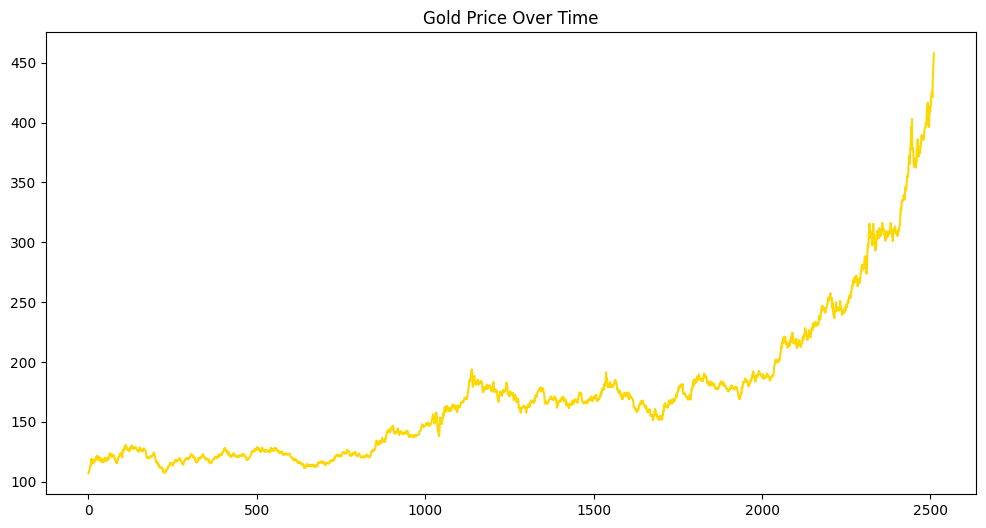

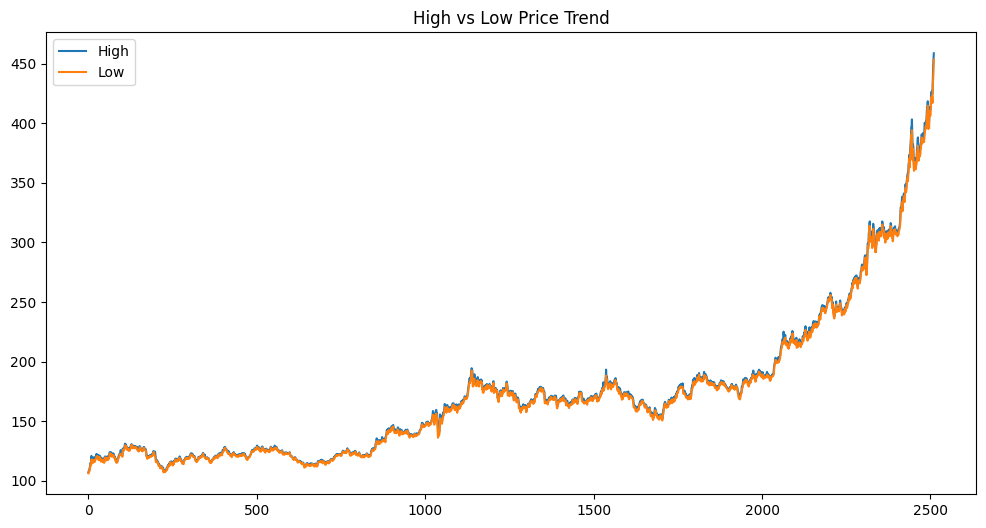

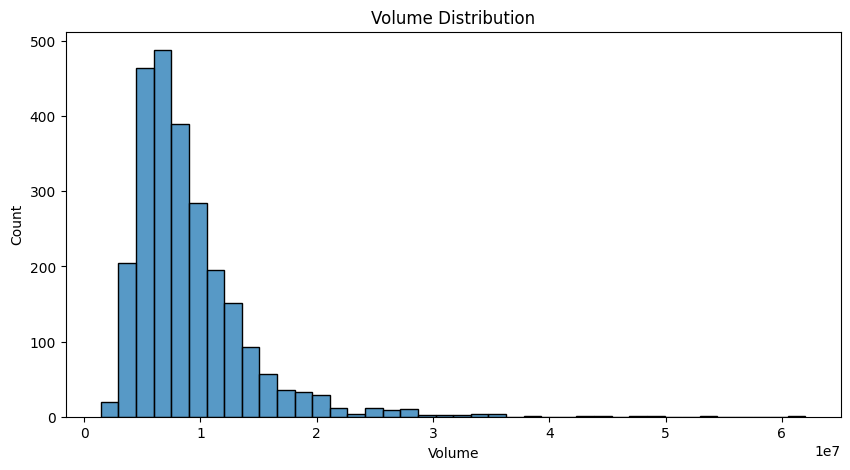

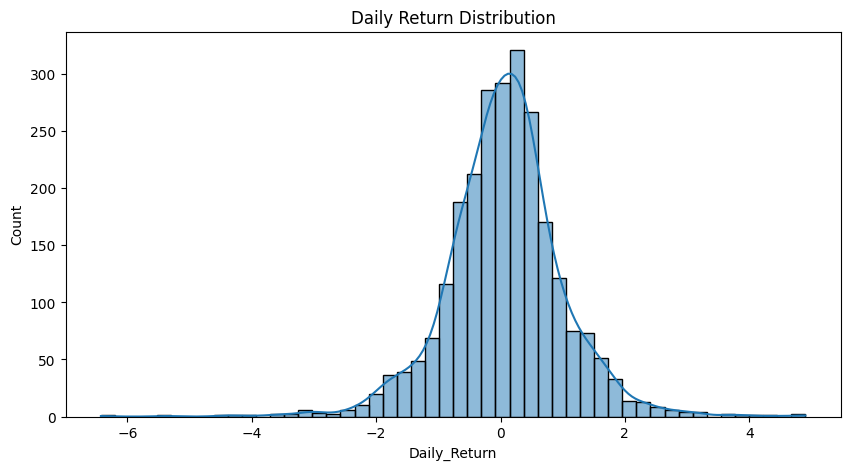

In [ ]:
# ====================================
# Exploratory Data Analysis (EDA)
# ====================================
plt.figure(figsize=(12,6))
plt.plot(df['Close'], color='gold')
plt.title("Gold Price Over Time")
plt.show()


# =================================
# High vs Low Price Analysis
# =================================
plt.figure(figsize=(12,6))
plt.plot(df['High'], label='High')
plt.plot(df['Low'], label='Low')
plt.legend()
plt.title("High vs Low Price Trend")
plt.show()

# ================================
# Volume Analysis
# =================================
import seaborn as sns
plt.figure(figsize=(10,5))
sns.histplot(df['Volume'], bins=40)
plt.title("Volume Distribution")
plt.show()

# ==================================
#Moving Average Analysis
# =================================
plt.figure(figsize=(10,5))
sns.histplot(df['Daily_Return'], bins=50, kde=True)
plt.title("Daily Return Distribution")
plt.show()

In [ ]:
# ====================================
# Preparing data for Prophet
# =====================================

df_prophet = df[['Date','Close']]
df_prophet.columns = ['ds','y']

In [ ]:
#================================
# TRAIN TEST SPLIT
# =================================

split = int(len(df_prophet)*0.8)
train = df_prophet[:split]
test = df_prophet[split:]

In [ ]:
# ============================
#BUILD PROPHET MODEL
# ============================

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    changepoint_prior_scale=0.5  # try 0.1, 0.5, 1
)
print("Model Trained Successfully ✅")

Model Trained Successfully ✅


In [35]:
print("Total rows:", len(df_prophet))
print("Train rows:", len(train))
print("Test rows:", len(test))

Total rows: 2511
Train rows: 2008
Test rows: 503


In [36]:
model.fit(train)
print("Model Fitted Successfully ✅")

15:32:16 - cmdstanpy - INFO - Chain [1] start processing
15:32:18 - cmdstanpy - INFO - Chain [1] done processing


Model Fitted Successfully ✅


In [ ]:
# ============================
# MAKE PREDICTIONS
# ============================

#create future dataframe for predictions
future = model.make_future_dataframe(periods=len(test))

#predict future values
forecast = model.predict(future)


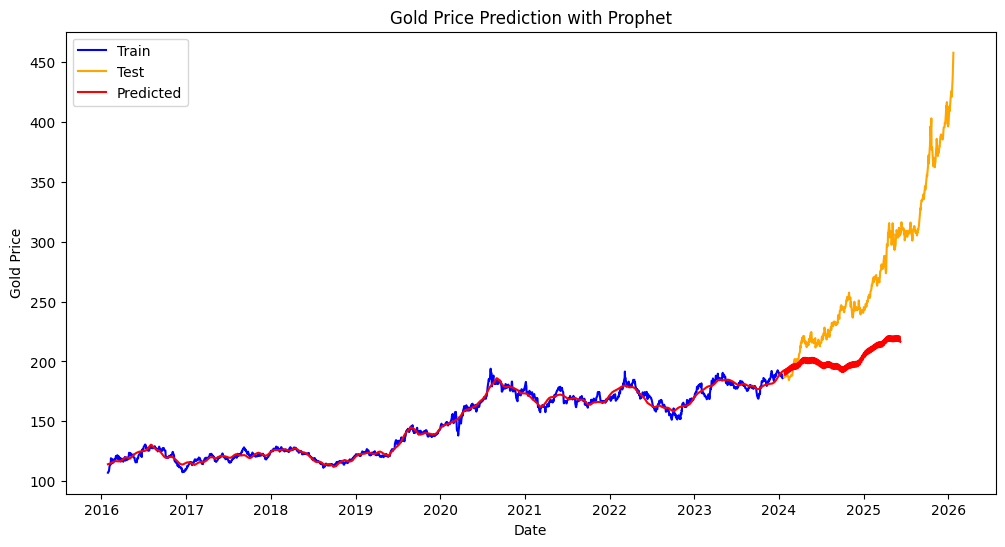

In [ ]:
#================================
# VISUALIZATION
# ================================

plt.figure(figsize=(12,6))
plt.plot(train['ds'], train['y'], label='Train', color='blue')
plt.plot(test['ds'], test['y'], label='Test', color='orange')
plt.plot(forecast['ds'], forecast['yhat'], label='Predicted', color='red')
plt.xlabel('Date')
plt.ylabel('Gold Price')
plt.title('Gold Price Prediction with Prophet')
plt.legend()
plt.show()

In [ ]:
# ===============================
# MODEL EVALUATION
# ================================


pred_test = forecast['yhat'][-len(test):].values

rmse = np.sqrt(mean_squared_error(test['y'], pred_test))
mae = mean_absolute_error(test['y'], pred_test)
r2 = r2_score(test['y'], pred_test)

print("RMSE:", round(rmse,2))
print("MAE:", round(mae,2))
print("R2 Score:", round(r2,3))

RMSE: 91.7
MAE: 73.32
R2 Score: -1.098


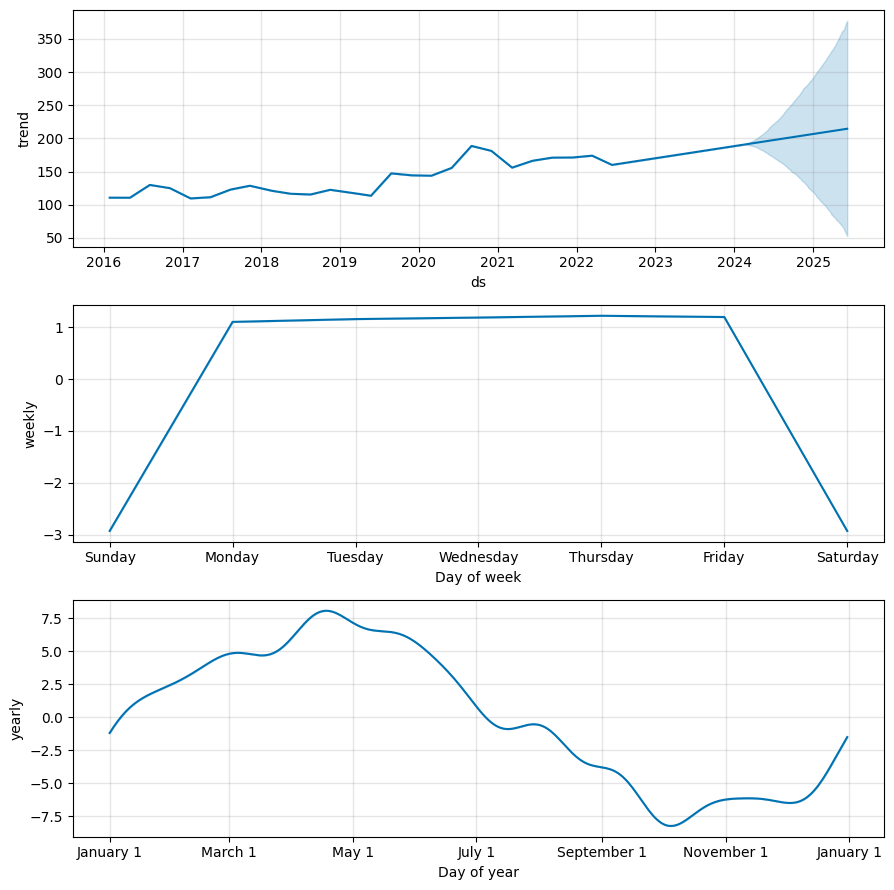

In [ ]:
# ==============================
#  COMPONENT ANALYSIS
# ===============================

model.plot_components(forecast)
plt.show()

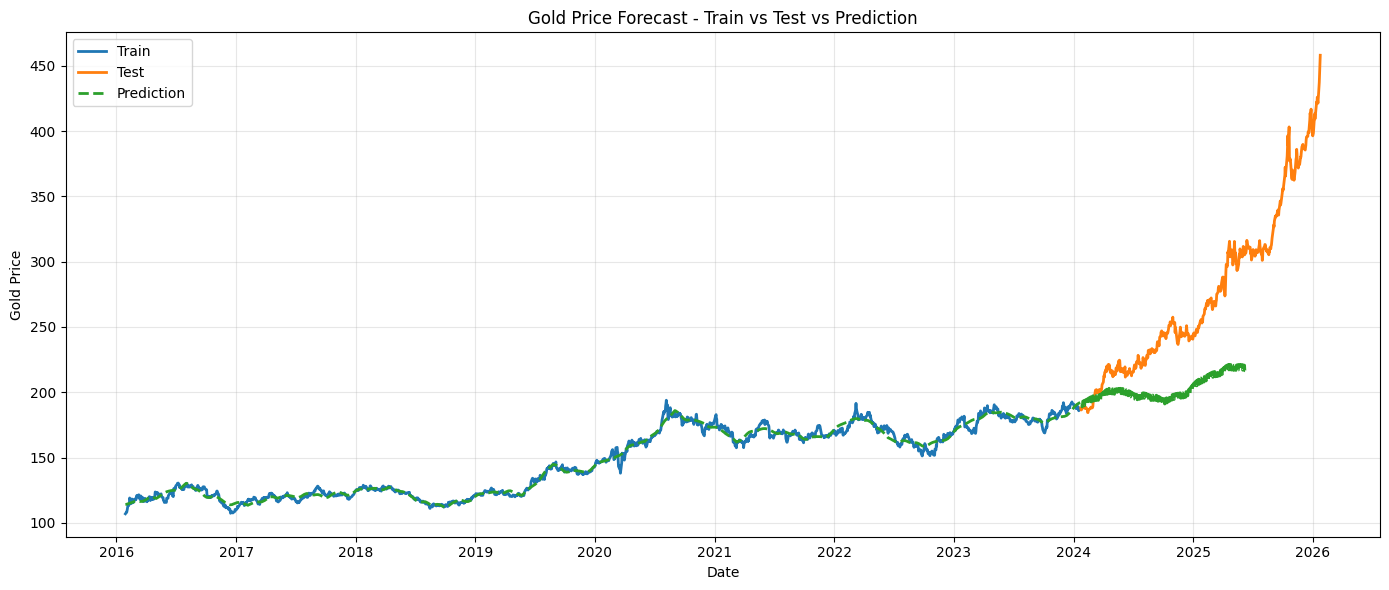

In [ ]:
# ===============================
# FINAL VISUALIZATION
# ===============================

plt.figure(figsize=(14,6))

plt.plot(train['ds'], train['y'], label="Train", linewidth=2)
plt.plot(test['ds'], test['y'], label="Test", linewidth=2)
plt.plot(forecast['ds'], forecast['yhat'], 
         label="Prediction", linestyle='--', linewidth=2)

plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.title("Gold Price Forecast - Train vs Test vs Prediction")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

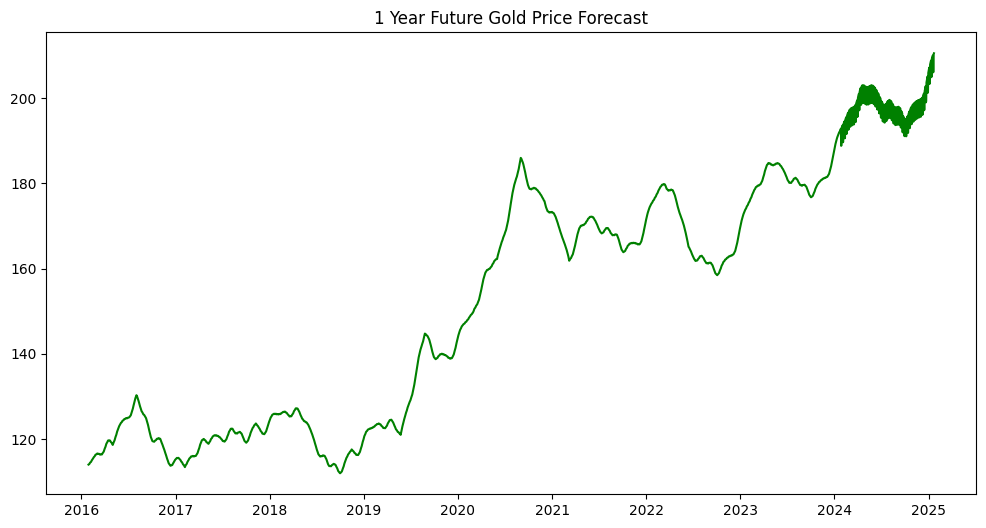

In [ ]:
#===============================
# FUTURE FORECAST (Next 365 Days)
#===============================


future_365 = model.make_future_dataframe(periods=365)
forecast_365 = model.predict(future_365)

plt.figure(figsize=(12,6))
plt.plot(forecast_365['ds'], forecast_365['yhat'], color='green')
plt.title("1 Year Future Gold Price Forecast")
plt.show()

In [ ]:


# ========================
# 12. FINAL METRICS TABLE
# ========================

# Store metrics in dictionary
results = {
    "Prophet Model": [rmse, mae, r2]
}

# Create DataFrame
results_df = pd.DataFrame(results, index=['RMSE','MAE','R2']).T

print(results_df)

print("PROJECT COMPLETED SUCCESSFULLY 🚀")



                    RMSE        MAE        R2
Prophet Model  91.703958  73.323641 -1.097537
PROJECT COMPLETED SUCCESSFULLY 🚀
